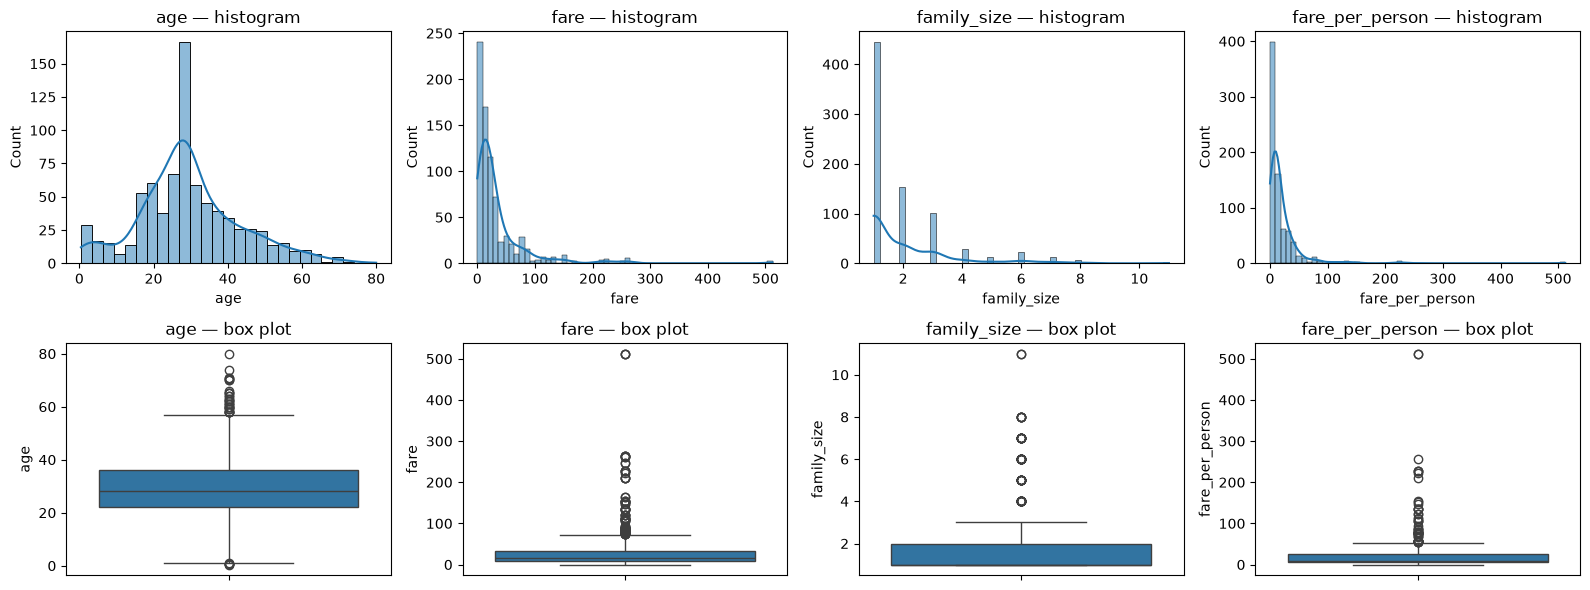

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("data/titanic_cleaned.csv")
numeric_cols = ["age", "fare", "family_size", "fare_per_person"]

fig, axes = plt.subplots(2, len(numeric_cols), figsize=(16, 6))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"{col} — histogram")
    sns.boxplot(y=df[col], ax=axes[1, i])
    axes[1, i].set_title(f"{col} — box plot")
plt.tight_layout()
plt.show()

In [2]:
df[numeric_cols].describe()

,age,fare,family_size,fare_per_person
count,782.000000,782.000000,782.000000,782.000000
mean,29.598363,34.595913,1.941176,21.166009
std,13.700341,52.176458,1.518682,37.772683
min,0.420000,0.000000,1.000000,0.000000
25%,22.000000,8.050000,1.000000,7.250000
50%,28.250000,15.875000,1.000000,8.755550
75%,36.000000,33.375000,2.000000,26.000000
max,80.000000,512.329200,11.000000,512.329200


In [3]:
skew_kurt = pd.DataFrame({
    "skewness": df[numeric_cols].skew(),
    "kurtosis": df[numeric_cols].kurt()
})
skew_kurt

,skewness,kurtosis
age,0.440512,0.601598
fare,4.583206,30.291539
family_size,2.276641,6.084482
fare_per_person,7.452226,79.470384


In [4]:
for col in numeric_cols:
    stat, p = stats.shapiro(df[col].sample(min(500, len(df)), random_state=42))
    print(f"{col}: Shapiro-Wilk p-value = {p:.5f} {'(likely NOT normal)' if p < 0.05 else '(consistent with normal)'}")

age: Shapiro-Wilk p-value = 0.00000 (likely NOT normal)
fare: Shapiro-Wilk p-value = 0.00000 (likely NOT normal)
family_size: Shapiro-Wilk p-value = 0.00000 (likely NOT normal)
fare_per_person: Shapiro-Wilk p-value = 0.00000 (likely NOT normal)


In [5]:
df["fare_log"] = np.log1p(df["fare"])  # log1p handles zero values safely
df["fare_per_person_log"] = np.log1p(df["fare_per_person"])

In [6]:
print("Before:", df["fare"].skew(), "| After log:", df["fare_log"].skew())

Before: 4.583205969233933 | After log: 0.42249028014673523


In [7]:
from sklearn.preprocessing import StandardScaler

cluster_features = ["age", "fare_log", "family_size"]
scaler = StandardScaler()
scaled = scaler.fit_transform(df[cluster_features])
scaled_df = pd.DataFrame(scaled, columns=[f"{c}_scaled" for c in cluster_features])
scaled_df.describe()

,age_scaled,fare_log_scaled,family_size_scaled
count,7.820000e+02,7.820000e+02,7.820000e+02
mean,5.906046e-17,-5.928761e-16,-1.362934e-17
std,1.000640e+00,1.000640e+00,1.000640e+00
min,-2.131118e+00,-3.153424e+00,-6.201291e-01
25%,-5.549662e-01,-8.674078e-01,-6.201291e-01
50%,-9.848121e-02,-2.207922e-01,-6.201291e-01
75%,4.675602e-01,5.175748e-01,3.875807e-02
max,3.681214e+00,3.323362e+00,5.968743e+00


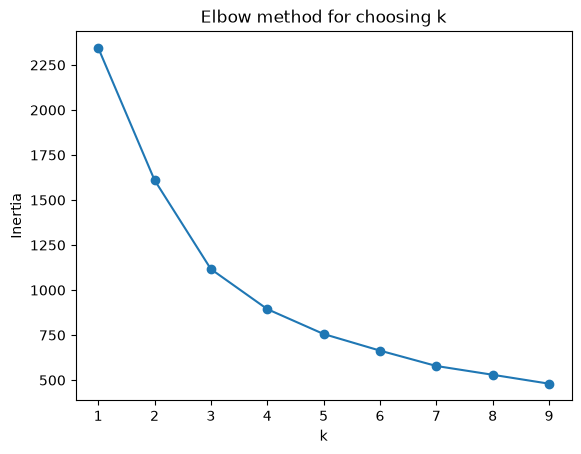

In [8]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method for choosing k")
plt.show()

## Distribution Review — Findings

| Column | Shape | Shapiro-Wilk | Transformation Applied | Reason |
|---|---|---|---|---|
| age | Mild right skew (0.44), roughly bell-shaped | Not normal (p<0.001) | None | Skew is mild; log transform would over-correct a nearly-usable distribution |
| fare | Heavy right skew (4.58), extreme outliers | Not normal (p<0.001) | log1p → skew reduced to 0.42 | Log transform brought this to near-symmetric, appropriate given the raw skew |
| family_size | Right-skewed (2.28), discrete/count data | Not normal (p<0.001) | None (used as-is, scaled) | Discrete count variable; log transform would distort its interpretability for clustering |
| fare_per_person | Extreme right skew (7.45) | Not normal (p<0.001) | Log available (fare_log used instead in clustering) | fare_log used as the representative fare feature to avoid redundancy with fare_per_person |

**Which assumptions hold:** None of the four numeric columns are normally 
distributed in their raw form (confirmed via Shapiro-Wilk, not assumed). 
Age comes closest to a usable shape without transformation.

**Which don't hold:** Fare and fare-derived columns are far from normal and 
require log transformation before use in any method assuming normality or 
relying on unscaled Euclidean distance.

**Transformations applied:** `fare_log = log1p(fare)` — chosen because it 
meaningfully reduced skew (4.58 → 0.42) without discarding any rows (log1p 
handles the zero-fare values safely, unlike plain log).

**Clustering-ready features:** age, fare_log, and family_size were selected, 
standardized via StandardScaler (mean 0, std 1 each), avoiding the pitfall of 
mixing unscaled variables into a distance-based method like K-Means.

**Choosing k:** The elbow method shows inertia dropping sharply through k=3, 
with diminishing returns beyond k=4 — k=3 or k=4 is a justified choice based 
on this curve, rather than an arbitrary pick.